# Homework11

## 1. Загальне використання генетичного алгоритму

In [28]:
import pygad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

products = [
    {'name': 'Refrigerator A', 'space': 0.751, 'price': 999.90},
    {'name': 'Cell phone', 'space': 0.00000899, 'price': 2199.12},
    {'name': 'TV 55', 'space': 0.400, 'price': 4346.99},
    {'name': "TV 50'", 'space': 0.290, 'price': 3999.90},
    {'name': "TV 42'", 'space': 0.200, 'price': 2999.00},
    {'name': "Notebook A", 'space': 0.00350, 'price': 2499.90},
    {'name': "Ventilator", 'space': 0.496, 'price': 199.90},
    {'name': "Microwave A", 'space': 0.0424, 'price': 308.66},
    {'name': "Microwave B", 'space': 0.0544, 'price': 429.90},
    {'name': "Microwave C", 'space': 0.0319, 'price': 299.29},
    {'name': "Refrigerator B", 'space': 0.635, 'price': 849.00},
    {'name': "Refrigerator C", 'space': 0.870, 'price': 1199.89},
    {'name': "Notebook B", 'space': 0.498, 'price': 1999.90},
    {'name': "Notebook C", 'space': 0.527, 'price': 3999.00}
]

spaces = np.array([p['space'] for p in products])
prices = np.array([p['price'] for p in products])
names = [p['name'] for p in products]

space_limit = 3.0

# --- Визначення фітнес-функції ---
def fitness_func(ga_instance, solution, solution_idx):
    # solution - це масив з 0 та 1 (взяти чи не взяти товар)
    
    total_space = np.sum(solution * spaces)
    total_price = np.sum(solution * prices)
    
    if total_space > space_limit:
        return 0  # Штраф за перевищення об'єму
    else:
        return total_price

# --- Експеримент з різними параметрами
def run_genetic_experiment():
    # Варіанти для дослідження
    crossover_types = ["single_point", "two_points", "uniform", "scattered"]
    mutation_types = ["random", "swap", "inversion", "scramble"]
    
    results = []

    print("Запуск експериментів...")
    
    for cross_type in crossover_types:
        for mut_type in mutation_types:
            
            # Створення екземпляра та налаштування параметрів
            ga_instance = pygad.GA(
                num_generations=50,         # Кількість поколінь
                num_parents_mating=5,       # Кількість батьків для парування
                fitness_func=fitness_func,  # Наша фітнес-функція
                sol_per_pop=10,             # Розмір популяції
                num_genes=len(products),    # Кількість генів = кількість товарів
                gene_type=int,              # Тип генів (цілі числа 0 або 1)
                init_range_low=0,           # Діапазон для ініціалізації
                init_range_high=2,          # (не включно, тобто 0 або 1)
                parent_selection_type="sss",# Тип селекції (Steady State Selection)
                keep_parents=1,             # Зберігати найкращих батьків
                crossover_type=cross_type,  # Тип кросинговеру (змінюється в циклі)
                mutation_type=mut_type,     # Тип мутації (змінюється в циклі)
                mutation_percent_genes=10,  # Відсоток генів для мутації
                random_seed=42              # Для відтворюваності результатів
            )
            
            ga_instance.run()
            solution, solution_fitness, solution_idx = ga_instance.best_solution()
            results.append({
                'Crossover': cross_type,
                'Mutation': mut_type,
                'Best Price': solution_fitness,
                'Space Used': np.sum(solution * spaces)
            })
            
    return pd.DataFrame(results)

df_results = run_genetic_experiment()

print("\nРезультати експериментів:")
print(df_results.sort_values(by='Best Price', ascending=False))

Запуск експериментів...

Результати експериментів:
       Crossover   Mutation  Best Price  Space Used
3   single_point   scramble    24281.55    2.917209
15     scattered   scramble    24281.55    2.917209
11       uniform   scramble    24281.55    2.917209
9        uniform       swap    24281.55    2.917209
13     scattered       swap    24281.55    2.917209
2   single_point  inversion    24081.56    2.798209
7     two_points   scramble    23982.26    2.885309
5     two_points       swap    23972.89    2.874809
14     scattered  inversion    22481.55    2.917209
10       uniform  inversion    22481.55    2.917209
0   single_point     random    21683.07    2.355409
4     two_points     random    21133.36    1.752309
1   single_point       swap    20173.79    2.874809
8        uniform     random    19683.97    2.358309
12     scattered     random    19683.97    2.358309
6     two_points  inversion        0.00    2.917209


На даному етапі виконали алгоритм з різними комбінаціями параметрів, та бачимо, що найдено цінностно однакове рішення в декількох комбінаціях:
- ціна 24281.55 
- при використаному просторі 2.917209. 

Таке рішення дали 3 кросовери з 4-х разом із мутацією scramble, та 2 кросовери разом із мутацією swap.\
У однієї комбінації при цьому стався вихід за ліміт об'єму - two_points + inversion.\
\
Роздивимось детально найкраще рішення:

In [29]:
# --- Детальний вивід найкращого рішення ---
# Вибір найкращих параметрів з датафрейму
best_row = df_results.loc[df_results['Best Price'].idxmax()]
print(f"\n--- Найкраща комбінація: {best_row['Crossover']} + {best_row['Mutation']} ---")

# Запустимо ще раз з найкращими параметрами, щоб показати товари
best_ga = pygad.GA(
    num_generations=100,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=len(products),
    gene_type=int,
    init_range_low=0,
    init_range_high=2,
    parent_selection_type="sss",
    keep_parents=1,
    crossover_type=best_row['Crossover'],
    mutation_type=best_row['Mutation'],
    mutation_percent_genes=10,
    random_seed=42
)
best_ga.run()

solution, solution_fitness, _ = best_ga.best_solution()

print(f"Максимальна ціна: {solution_fitness}")
print(f"Зайнятий об'єм: {np.sum(solution * spaces):.3f} з {space_limit}")
print("\nОбрані товари:")
for i, selected in enumerate(solution):
    if selected == 1:
        print(f"- {names[i]} (Ціна: {prices[i]}, Об'єм: {spaces[i]})")


--- Найкраща комбінація: single_point + scramble ---
Максимальна ціна: 24281.55
Зайнятий об'єм: 2.917 з 3.0

Обрані товари:
- Cell phone (Ціна: 2199.12, Об'єм: 8.99e-06)
- TV 55 (Ціна: 4346.99, Об'єм: 0.4)
- TV 50' (Ціна: 3999.9, Об'єм: 0.29)
- TV 42' (Ціна: 2999.0, Об'єм: 0.2)
- Notebook A (Ціна: 2499.9, Об'єм: 0.0035)
- Microwave A (Ціна: 308.66, Об'єм: 0.0424)
- Microwave B (Ціна: 429.9, Об'єм: 0.0544)
- Microwave C (Ціна: 299.29, Об'єм: 0.0319)
- Refrigerator C (Ціна: 1199.89, Об'єм: 0.87)
- Notebook B (Ціна: 1999.9, Об'єм: 0.498)
- Notebook C (Ціна: 3999.0, Об'єм: 0.527)


## 2. Експерименти з параметрами

На цьому етапи відберемо деякі параметри з попереднього пункту, та застосуємо експерименти подібного роду, але з різним розміром популяції, та побачимо різницю у зміні ціни за популяціями

In [ ]:
def advanced_experiment():
    crossover_types = ["single_point", "uniform", "scattered"]
    mutation_types = ["swap", "scramble", "inversion"]
    pop_sizes = [10, 50]
    
    results = []

    print("Запуск експериментів...")
    
    for cross in crossover_types:
        for mut in mutation_types:
            for pop_size in pop_sizes:
                
                # прогін для кожної комбінації 3 рази з різними сідами, щоб уникнути випадковості
                fitness_runs = []
                
                for run_seed in range(3): 
                    ga_instance = pygad.GA(
                        num_generations=60,
                        num_parents_mating=int(pop_size/2),
                        fitness_func=fitness_func,
                        sol_per_pop=pop_size,
                        num_genes=len(products),
                        gene_type=int,
                        init_range_low=0,
                        init_range_high=2,
                        parent_selection_type="sss",
                        keep_parents=1,
                        crossover_type=cross,
                        mutation_type=mut,
                        mutation_percent_genes=15, # Трохи підвищимо мутацію
                        random_seed=run_seed # Змінюємо сід!
                    )
                    ga_instance.run()
                    sol, sol_fit, _ = ga_instance.best_solution()
                    fitness_runs.append(sol_fit)
                
                # Записуємо середнє значення за 3 прогони
                avg_fitness = np.mean(fitness_runs)
                results.append({
                    'Crossover': cross,
                    'Mutation': mut,
                    'Pop Size': pop_size,
                    'Avg Best Price': avg_fitness,
                    'Stability (Std)': np.std(fitness_runs) # Наскільки стабільний результат
                })
                
    return pd.DataFrame(results)

df_advanced = advanced_experiment()

print("\n--- Результати експериментів ---")
print(df_advanced.sort_values(by='Avg Best Price', ascending=False))


Запуск експериментів...

--- Результати експериментів ---
       Crossover   Mutation  Pop Size  Avg Best Price  Stability (Std)
3   single_point   scramble        50    24281.550000         0.000000
2   single_point   scramble        10    24281.550000         0.000000
15     scattered   scramble        50    24281.550000         0.000000
16     scattered  inversion        10    24281.550000         0.000000
5   single_point  inversion        50    24281.550000         0.000000
9        uniform   scramble        50    24281.550000         0.000000
10       uniform  inversion        10    24281.550000         0.000000
8        uniform   scramble        10    24214.886667        94.276190
14     scattered   scramble        10    24214.886667        94.276190
1   single_point       swap        50    24148.223333        94.276190
0   single_point       swap        10    23271.883333      1289.058215
12     scattered       swap        10    22795.333333      1635.546357
6        uniform   

Далі я відбираю деякі параметри з отриманих результатів, і відобаржу графіки сходження до рішення в залежності від номеру популяції для різних випадків: велика і мала популяція.

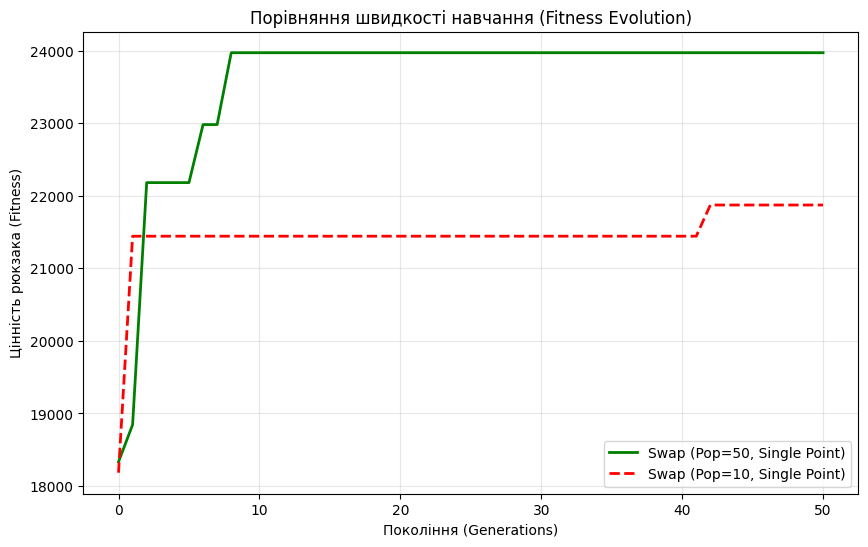

In [33]:
# --- Порівняльний аналіз з різними популяціями ---

# 1. Запуск з великою популяцією
ga_strong = pygad.GA(
    num_generations=50,
    num_parents_mating=25,
    fitness_func=fitness_func,
    sol_per_pop=50,          # Велика популяція
    num_genes=len(products),
    gene_type=int,
    init_range_low=0,
    init_range_high=2,
    crossover_type="single_point",
    mutation_type="swap",
    mutation_percent_genes=15,
    random_seed=42
)
ga_strong.run()

# 2. Запуск з малою популяцією
ga_weak = pygad.GA(
    num_generations=50,
    num_parents_mating=2,
    fitness_func=fitness_func,
    sol_per_pop=10,           # Мала популяція
    num_genes=len(products),
    gene_type=int,
    init_range_low=0,
    init_range_high=2,
    crossover_type="single_point",
    mutation_type="swap",
    mutation_percent_genes=15,      # Мала мутація
    random_seed=42
)
ga_weak.run()

# 3. Побудова спільного графіку
plt.figure(figsize=(10, 6))
plt.plot(ga_strong.best_solutions_fitness, label='Swap (Pop=50, Single Point)', color='green', linewidth=2)
plt.plot(ga_weak.best_solutions_fitness, label='Swap (Pop=10, Single Point)', color='red', linestyle='--', linewidth=2)

plt.title('Порівняння швидкості навчання (Fitness Evolution)')
plt.xlabel('Покоління (Generations)')
plt.ylabel('Цінність рюкзака (Fitness)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Як висновок, бачимо, що розмір популяції може не тільки впливати на цінність рішення, отримуючи більшу фітнес-функцію, але і здатен вплинути на те, як швидко отримуєтсья достатньо хороше рішення.

## 3. Дослідження сценарію раптового сплеску мутацій

На даному етапі не вдалось простим рішенням змінити параметри відсотку мутації і лише самою підміною значення вплинути на зміни у алгоритми. Замість цього прийшлось додати код для ручних зміни у популяції, обнулення історії - лише так стійкість алгоритму вдалось порушити, і показати що в принципі можливо змоделювати глобальну зміну умов середовища.

Запуск симуляції...
⚠️ GEN 20: ☢️ Катастрофа! (Ручне пошкодження популяції та Keep Parents = 0)
✅ GEN 30: 🌤️ Відновлення екосистеми (Keep Parents = 1)


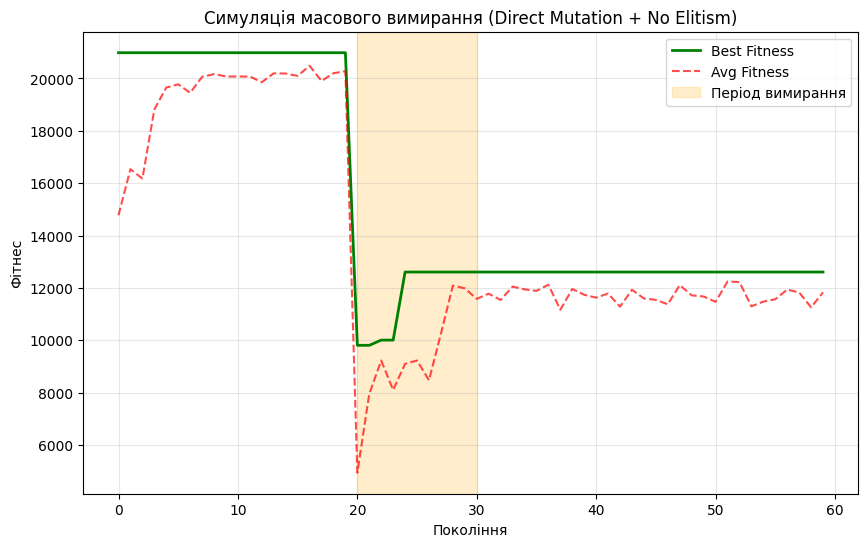

In [32]:
# --- Змінні для збереження історії ---
fitness_history_best = []
fitness_history_avg = []

def fitness_func(ga_instance, solution, solution_idx):
    total_space = np.sum(solution * spaces)
    total_price = np.sum(solution * prices)
    if total_space > space_limit:
        return 0
    else:
        return total_price
    
# --- Функція "Менеджер катастроф" (Callback) ---
# Ця функція запускається PyGad'ом після кожного покоління
def mutation_scheduler(ga_instance):
    generation = ga_instance.generations_completed
    pop_fitness = ga_instance.last_generation_fitness
    
    # Зберігаємо статистику
    fitness_history_best.append(np.max(pop_fitness))
    fitness_history_avg.append(np.mean(pop_fitness))
    
    # Сценарій катастрофи
    if generation == 20:
        print(f"⚠️ GEN {generation}: ☢️ Катастрофа! (Ручне пошкодження популяції та Keep Parents = 0)")
        
        ga_instance.keep_parents = 0  # Тимчасово вимикаємо елітизм
        
        # Ручне пошкодження генів
        pop_size = ga_instance.population.shape[0]
        num_genes = ga_instance.population.shape[1]
        
        # Псуємо гени кожного індивіда в популяції
        for i in range(pop_size):
            # Агресивна мутація: 80% генів інвертуються, щоб точно вбити фітнес
            mutation_mask = np.random.choice([0, 1], size=num_genes, p=[0.2, 0.8])
            ga_instance.population[i] = np.where(mutation_mask == 1, 1 - ga_instance.population[i], ga_instance.population[i])
            
        # Примусово ставимо всім поточним особам фітнес = 0.
        # Тепер PyGad не вважатиме їх "елітними"
        ga_instance.last_generation_fitness[:] = 0 
        
        ga_instance.best_solution_fitness = -1
            
    elif generation == 30:
        print(f"✅ GEN {generation}: 🌤️ Відновлення екосистеми (Keep Parents = 1)")
        ga_instance.keep_parents = 1  # Відновлюємо елітизм

# Виберемо малу популяцію, маючи на меті застрягти в локальному мінімумі
ga_dynamic = pygad.GA(
    num_generations=60,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=len(products),
    gene_type=int,
    init_range_low=0,
    init_range_high=2,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,    # Стартова мала мутація
    keep_parents=1,             # За замовчуванням елітизм увімкнено
    on_generation=mutation_scheduler, # колбек для динамічної мутації
    random_seed=42
)

print("Запуск симуляції...")
ga_dynamic.run()

# --- Візуалізація ---
plt.figure(figsize=(10, 6))
plt.plot(fitness_history_best, label='Best Fitness', color='green', linewidth=2)
plt.plot(fitness_history_avg, label='Avg Fitness', color='red', linestyle='--', alpha=0.7)
plt.axvspan(20, 30, color='orange', alpha=0.2, label='Період вимирання') 
plt.title('Симуляція масового вимирання (Direct Mutation + No Elitism)')
plt.xlabel('Покоління')
plt.ylabel('Фітнес')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На графіку видно, що після примусового пошкодження популяції на 20-му поколінні фітнес впав критично. Система змогла частково відновитися (зростання з 5000 до 12500), але застрягла в новому локальному оптимумі, значно нижчому за початковий рівень (21000).

Експеримент показав, що хоча генетичний алгоритм здатний до швидкого відновлення після катастрофічних подій, він не завжди повертається до попереднього глобального оптимуму. Повна втрата еліти відкидає еволюцію на початковий етап, і повторне досягнення піку не гарантоване без достатньої кількості часу.

Це доводить, що збереження елітних особин (Elitism) є критично важливим механізмом не лише для покращення результату у генетичному алгоритмі, реалізованому в PyGAD. 